# 08 - Extended fairness analysis

Operates on saved `test_outputs.npz` from notebooks 04 (VAE-IMU-reg), 05 (VAE-EMG-reg), 06 (DVAE-IMU), 07 (DVAE-EMG). No retraining.

**Metrics added beyond Rahman (SP/PRD/NRD):**
- **Disparate Impact (DI)** at threshold 9.1 kg — Mehrabi et al. 2021, Pessach & Shmueli 2020.
- **Bounded Group Loss ratio** = max group MAE / min group MAE — Hort et al. 2022 (regression-native fairness).
- **Per-group calibration plot** — predicted vs true mass per group (visualizes SP/PRD/NRD as a curve).

**Sensitive attributes:** sex (Female/Male), age (young = P1-P20, old = P21-P40).

**Caveat for age:** The 80/20 split was sex-stratified, not age-stratified. Test set has 1 young + 7 old (IMU) or 2 young + 6 old (EMG), so age metrics describe a single young subject (P2) and are not statistically meaningful. They are reported as descriptive only; a proper age-fairness study would require re-splitting and retraining with age stratification.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(r"C:\Users\lilin\OneDrive\Desktop\ECE5424\Capstone_Project")
RES = ROOT / "VAE" / "Results"
OUT = RES / "fairness_analysis"
OUT.mkdir(parents=True, exist_ok=True)

RUNS = {
    "VAE-IMU-reg":  RES / "vae_imu_reg"  / "test_outputs.npz",
    "DVAE-IMU":     RES / "dvae_imu"     / "test_outputs.npz",
    "VAE-EMG-reg":  RES / "vae_emg_reg"  / "test_outputs.npz",
    "DVAE-EMG":     RES / "dvae_emg"     / "test_outputs.npz",
}
LOAD_BINS = np.array([2.3, 4.5, 6.8, 9.1, 11.3])
HEAVY_THR = 9.1   # threshold for disparate impact (top 2 of 5 classes)

def load_run(p):
    d = np.load(p, allow_pickle=True)
    out = {k: d[k] for k in d.keys()}
    pid = out["participant"]
    out["age"] = np.array(["young" if int(str(x)[1:]) <= 20 else "old" for x in pid])
    return out

data = {tag: load_run(p) for tag, p in RUNS.items()}
for tag, d in data.items():
    print(f"{tag:14s}  n={len(d['mass_true'])}  young={(d['age']=='young').sum()}  old={(d['age']=='old').sum()}")

VAE-IMU-reg     n=960  young=120  old=840
DVAE-IMU        n=960  young=120  old=840
VAE-EMG-reg     n=959  young=240  old=719
DVAE-EMG        n=959  young=240  old=719


In [2]:
# ---- fairness metric functions ----

def group_metrics(mass_true, mass_pred, group, group_a, group_b, heavy_thr=HEAVY_THR):
    """Compute per-group + cross-group fairness metrics for a binary protected attr.

    Returns dict including: MAE per group, mean signed error per group,
    SP, PRD, NRD (Rahman 2025), DI (Mehrabi/Pessach), BGL ratio (Hort).
    """
    a = group == group_a; b = group == group_b
    err = mass_pred - mass_true   # signed: positive = over-predicted

    mae_a = np.abs(err[a]).mean(); mae_b = np.abs(err[b]).mean()
    rmse_a = np.sqrt((err[a]**2).mean()); rmse_b = np.sqrt((err[b]**2).mean())
    se_a = err[a].mean(); se_b = err[b].mean()

    # Rahman SP/PRD/NRD
    SP = mass_pred[a].mean() - mass_pred[b].mean()
    PRD = abs(np.maximum(0, mass_true[a] - mass_pred[a]).mean()
              - np.maximum(0, mass_true[b] - mass_pred[b]).mean())
    NRD = abs(np.minimum(0, mass_true[a] - mass_pred[a]).mean()
              - np.minimum(0, mass_true[b] - mass_pred[b]).mean())

    # Disparate Impact: P(pred >= heavy_thr | group) ratio
    p_heavy_a = (mass_pred[a] >= heavy_thr).mean()
    p_heavy_b = (mass_pred[b] >= heavy_thr).mean()
    DI = p_heavy_a / p_heavy_b if p_heavy_b > 0 else np.nan

    # Bounded Group Loss ratio (regression-native fairness summary)
    BGL_ratio = max(mae_a, mae_b) / min(mae_a, mae_b) if min(mae_a, mae_b) > 0 else np.nan

    return {
        f"n_{group_a}": int(a.sum()), f"n_{group_b}": int(b.sum()),
        f"MAE_{group_a}": mae_a, f"MAE_{group_b}": mae_b,
        f"RMSE_{group_a}": rmse_a, f"RMSE_{group_b}": rmse_b,
        f"signed_err_{group_a}": se_a, f"signed_err_{group_b}": se_b,
        "SP_kg": SP, "PRD_kg": PRD, "NRD_kg": NRD,
        f"P(pred>={heavy_thr})_{group_a}": p_heavy_a,
        f"P(pred>={heavy_thr})_{group_b}": p_heavy_b,
        "DI": DI,
        "BGL_ratio": BGL_ratio,
    }

def fmt(v):
    if isinstance(v, (int, np.integer)): return f"{v:d}"
    if np.isnan(v): return "nan"
    return f"{v:+.3f}" if isinstance(v, float) and abs(v) < 100 else f"{v:.3f}"


In [3]:
# ---- table 1: fairness by SEX ----
rows = []
for tag, d in data.items():
    m = group_metrics(d["mass_true"], d["mass_pred"], d["sex"], "Female", "Male")
    rows.append({"run": tag, "MAE_overall": np.abs(d["mass_pred"] - d["mass_true"]).mean(), **m})
sex_df = pd.DataFrame(rows)
sex_df.to_csv(OUT / "fairness_by_sex.csv", index=False)

show = ["run", "MAE_overall", "MAE_Female", "MAE_Male",
        "signed_err_Female", "signed_err_Male",
        "SP_kg", "PRD_kg", "NRD_kg", "DI", "BGL_ratio"]
print("Fairness by SEX (DI threshold = 9.1 kg, ideal: SP/PRD/NRD=0, DI=1, BGL=1)")
print(sex_df[show].to_string(index=False, float_format=lambda x: f"{x:+.3f}"))

Fairness by SEX (DI threshold = 9.1 kg, ideal: SP/PRD/NRD=0, DI=1, BGL=1)
        run  MAE_overall  MAE_Female  MAE_Male  signed_err_Female  signed_err_Male  SP_kg  PRD_kg  NRD_kg     DI  BGL_ratio
VAE-IMU-reg       +2.238      +1.969    +2.507             -0.306           +0.659 -0.965  +0.214  +0.752 +0.873     +1.273
   DVAE-IMU       +2.184      +1.951    +2.417             -0.030           +0.702 -0.732  +0.133  +0.599 +0.826     +1.239
VAE-EMG-reg       +2.369      +2.354    +2.384             +0.002           -0.280 +0.282  +0.156  +0.126 +1.201     +1.013
   DVAE-EMG       +2.371      +2.342    +2.399             +0.206           -0.223 +0.429  +0.243  +0.186 +1.194     +1.024


In [4]:
# ---- table 2: fairness by AGE (descriptive only; tiny young n) ----
rows = []
for tag, d in data.items():
    m = group_metrics(d["mass_true"], d["mass_pred"], d["age"], "young", "old")
    rows.append({"run": tag, "MAE_overall": np.abs(d["mass_pred"] - d["mass_true"]).mean(), **m})
age_df = pd.DataFrame(rows)
age_df.to_csv(OUT / "fairness_by_age.csv", index=False)

show = ["run", "n_young", "n_old", "MAE_young", "MAE_old",
        "signed_err_young", "signed_err_old",
        "SP_kg", "PRD_kg", "NRD_kg", "DI", "BGL_ratio"]
print("Fairness by AGE (descriptive only — see notebook header for caveat)")
print(age_df[show].to_string(index=False, float_format=lambda x: f"{x:+.3f}"))

Fairness by AGE (descriptive only — see notebook header for caveat)
        run  n_young  n_old  MAE_young  MAE_old  signed_err_young  signed_err_old  SP_kg  PRD_kg  NRD_kg     DI  BGL_ratio
VAE-IMU-reg      120    840     +2.311   +2.228            +0.823          +0.084 +0.739  +0.328  +0.411 +1.635     +1.037
   DVAE-IMU      120    840     +2.341   +2.161            +0.893          +0.256 +0.636  +0.229  +0.408 +1.647     +1.083
VAE-EMG-reg      240    719     +2.398   +2.360            +0.579          -0.378 +0.957  +0.459  +0.498 +1.084     +1.016
   DVAE-EMG      240    719     +2.599   +2.295            +0.465          -0.167 +0.631  +0.164  +0.468 +1.118     +1.133


In [5]:
# ---- VAE -> DVAE delta table (the 'what did the adversary buy us' figure) ----
pairs = [("VAE-IMU-reg", "DVAE-IMU", "IMU"),
         ("VAE-EMG-reg", "DVAE-EMG", "EMG")]
rows = []
for vae, dvae, mod in pairs:
    a = sex_df[sex_df.run == vae].iloc[0]
    b = sex_df[sex_df.run == dvae].iloc[0]
    rows.append({
        "modality": mod,
        "MAE VAE": a["MAE_overall"], "MAE DVAE": b["MAE_overall"],
        "SP VAE": a["SP_kg"], "SP DVAE": b["SP_kg"],
        "|signed F-M| VAE": abs(a["signed_err_Female"] - a["signed_err_Male"]),
        "|signed F-M| DVAE": abs(b["signed_err_Female"] - b["signed_err_Male"]),
        "BGL VAE": a["BGL_ratio"], "BGL DVAE": b["BGL_ratio"],
        "DI VAE": a["DI"], "DI DVAE": b["DI"],
    })
delta_df = pd.DataFrame(rows)
delta_df.to_csv(OUT / "vae_vs_dvae_summary.csv", index=False)
print("VAE -> DVAE comparison (sex):")
print(delta_df.to_string(index=False, float_format=lambda x: f"{x:+.3f}"))

VAE -> DVAE comparison (sex):
modality  MAE VAE  MAE DVAE  SP VAE  SP DVAE  |signed F-M| VAE  |signed F-M| DVAE  BGL VAE  BGL DVAE  DI VAE  DI DVAE
     IMU   +2.238    +2.184  -0.965   -0.732            +0.965             +0.732   +1.273    +1.239  +0.873   +0.826
     EMG   +2.369    +2.371  +0.282   +0.429            +0.282             +0.429   +1.013    +1.024  +1.201   +1.194


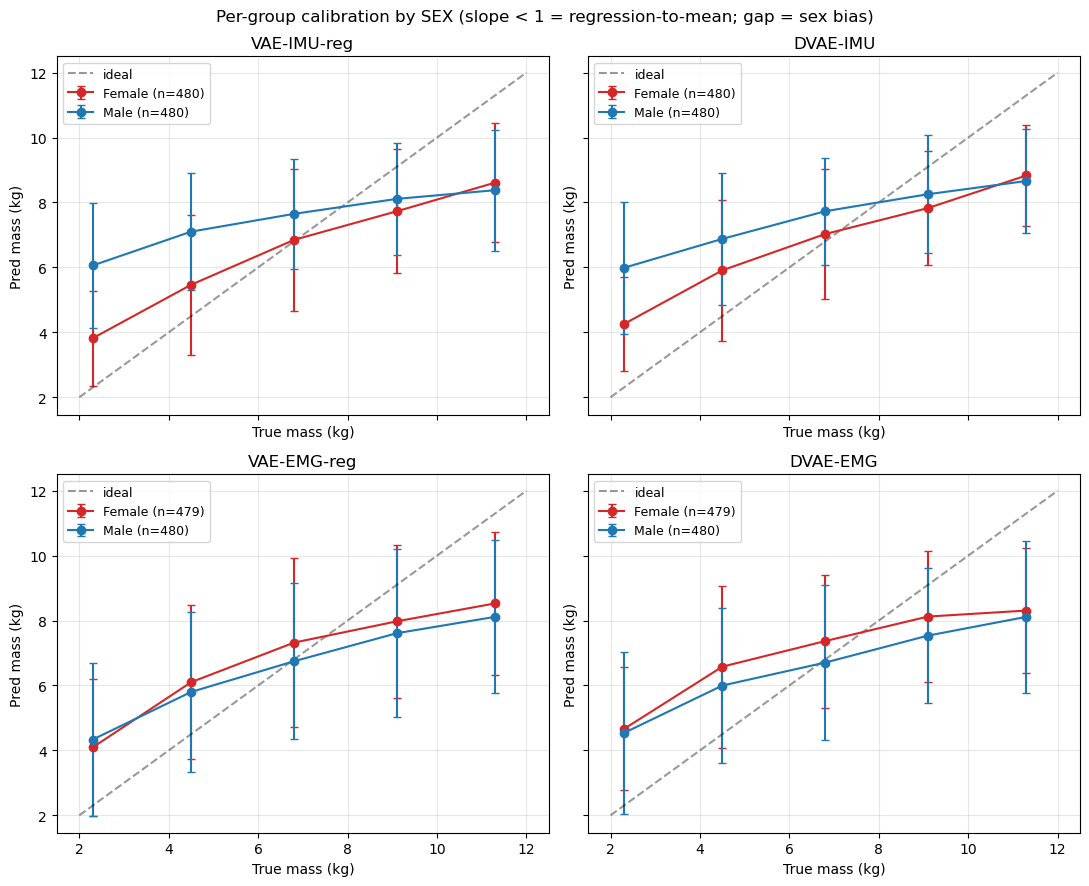

In [6]:
# ---- calibration plot by SEX ----
def calibration_curve(mass_true, mass_pred, group, group_label):
    m = group == group_label
    out = []
    for b in LOAD_BINS:
        sel = m & (np.argmin(np.abs(mass_true[:, None] - LOAD_BINS), axis=1) ==
                   np.where(LOAD_BINS == b)[0][0])
        if sel.any():
            out.append((b, mass_pred[sel].mean(), mass_pred[sel].std(), int(sel.sum())))
    return np.array(out)

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
for ax, (tag, d) in zip(axes.flat, data.items()):
    for s_label, color in [("Female", "tab:red"), ("Male", "tab:blue")]:
        c = calibration_curve(d["mass_true"], d["mass_pred"], d["sex"], s_label)
        if len(c):
            ax.errorbar(c[:, 0], c[:, 1], yerr=c[:, 2], fmt="o-",
                        color=color, label=f"{s_label} (n={int(c[:,3].sum())})", capsize=3)
    ax.plot([2, 12], [2, 12], "k--", alpha=0.4, label="ideal")
    ax.set_title(tag); ax.set_xlabel("True mass (kg)"); ax.set_ylabel("Pred mass (kg)")
    ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=9)
fig.suptitle("Per-group calibration by SEX (slope < 1 = regression-to-mean; gap = sex bias)")
fig.tight_layout()
fig.savefig(OUT / "calibration_by_sex.png", dpi=150)
plt.show()

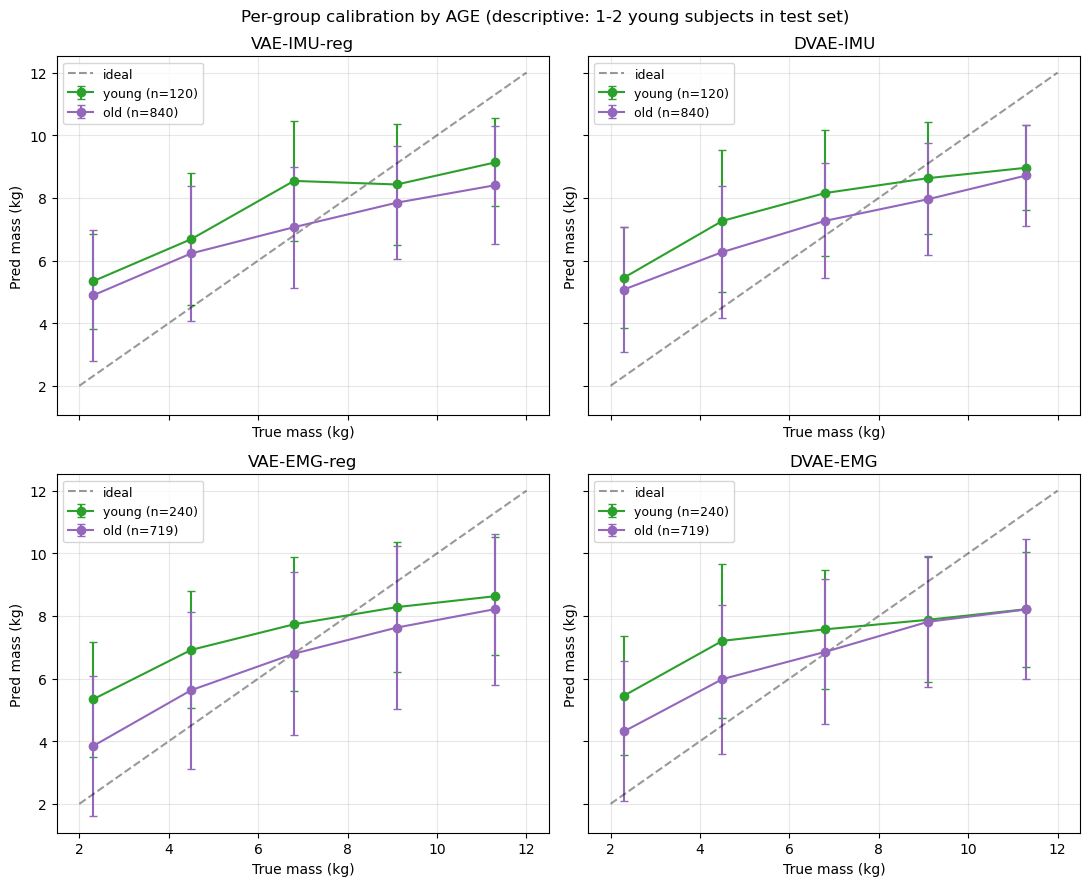

In [7]:
# ---- calibration plot by AGE (descriptive only) ----
fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
for ax, (tag, d) in zip(axes.flat, data.items()):
    for a_label, color in [("young", "tab:green"), ("old", "tab:purple")]:
        c = calibration_curve(d["mass_true"], d["mass_pred"], d["age"], a_label)
        if len(c):
            ax.errorbar(c[:, 0], c[:, 1], yerr=c[:, 2], fmt="o-",
                        color=color, label=f"{a_label} (n={int(c[:,3].sum())})", capsize=3)
    ax.plot([2, 12], [2, 12], "k--", alpha=0.4, label="ideal")
    ax.set_title(tag); ax.set_xlabel("True mass (kg)"); ax.set_ylabel("Pred mass (kg)")
    ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=9)
fig.suptitle("Per-group calibration by AGE (descriptive: 1-2 young subjects in test set)")
fig.tight_layout()
fig.savefig(OUT / "calibration_by_age.png", dpi=150)
plt.show()

In [8]:
# ---- final compact JSON with everything for the report ----
def json_safe(obj):
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, (np.integer,)): return int(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    if isinstance(obj, dict): return {k: json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list): return [json_safe(v) for v in obj]
    return obj

summary = {
    "description": "Extended fairness metrics over saved test outputs of notebooks 04, 05, 06, 07.",
    "heavy_threshold_kg": HEAVY_THR,
    "by_sex": json_safe(sex_df.to_dict(orient="records")),
    "by_age": json_safe(age_df.to_dict(orient="records")),
    "vae_vs_dvae": json_safe(delta_df.to_dict(orient="records")),
    "age_caveat": "Test split was sex-stratified, not age-stratified; n_young is 1-2 subjects so age metrics are descriptive only.",
}
with open(OUT / "fairness_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved to:", OUT)
print("Files:", [p.name for p in OUT.iterdir()])

Saved to: C:\Users\lilin\OneDrive\Desktop\ECE5424\Capstone_Project\VAE\Results\fairness_analysis
Files: ['calibration_by_age.png', 'calibration_by_sex.png', 'fairness_by_age.csv', 'fairness_by_sex.csv', 'fairness_summary.json', 'vae_vs_dvae_summary.csv']
